In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Configure visualization settings
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

In [4]:
"""
SECTION 1: DATA LOADING FROM EDA
"""

# Load the cleaned dataframe from EDA notebook
with open('df_cleaned.pkl', 'rb') as f:
    df = pickle.load(f)

# Identify target column and feature columns
label_col = next((c for c in df.columns if c.lower() == 'label'), None)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Cleaned dataframe loaded from EDA")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Target variable: {label_col}")
print(f"Class distribution:\n{df[label_col].value_counts()}")


Cleaned dataframe loaded from EDA
Dataset shape: 610794 rows x 8 columns
Target variable: Label
Class distribution:
Label
BENIGN              417035
DoS Hulk            172849
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Heartbleed              11
Name: count, dtype: int64


In [5]:
"""
SECTION 2: FEATURE ENGINEERING AND PREPROCESSING
"""

# Identify features (exclude target)
features = [col for col in df.columns if col != label_col]
X = df[features].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Encode target variable using LabelEncoder
le_target = LabelEncoder()
y = le_target.fit_transform(df[label_col])

print(f"\nFeature Engineering Summary:")
print(f"Total features: {X.shape[1]}")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"Target classes: {le_target.classes_}")

transformers = []
if numeric_features:
    transformers.append(('num', RobustScaler(), numeric_features))
if categorical_features:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)

print(f"\nPreprocessor configured to scale numeric features and encode categorical features.")
print(f"Training data shape: {X.shape}")


Feature Engineering Summary:
Total features: 7
Numeric features: ['Destination Port', 'Flow Duration', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow IAT Mean', 'FIN Flag Count', 'ACK Flag Count']
Categorical features: []
Target classes: ['BENIGN' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest' 'DoS slowloris'
 'Heartbleed']

Preprocessor configured to scale numeric features and encode categorical features.
Training data shape: (610794, 7)


In [6]:
"""
SECTION 3: APPROACH 1 - TRAIN/VALIDATION/TEST SPLIT WITH GRID SEARCH
"""

# Split data: 60% train, 20% validation, 20% test (maintaining class distribution with stratify)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Train/Val/Test split results for each ML model
print(f"Data Split for Approach 1 (Train/Val/Test):")
print(f"  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Define hyperparameter grids for pipeline classifiers
# class_weight='balanced' compensates for severe class imbalance (~40000:1 ratio)
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0, 10],
        'classifier__solver': ['lbfgs', 'liblinear', 'saga'],
        'classifier__max_iter': [200, 500]
    },
    'Decision Tree': {
        'classifier__max_depth': [5, 10, 20],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 4],
        'classifier__criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [10, 20],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 4],
        'classifier__criterion': ['gini', 'entropy']
    }
}

# Pipeline helper functions

def build_pipeline(estimator):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', estimator)
    ])


def run_grid_search(estimator, param_grid, X_train, y_train, cv):
    pipeline = build_pipeline(estimator)
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='f1_macro',  # macro treats all classes equally regardless of size
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    return grid


def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

# Grid Search on train/validation split using PredefinedSplit
results_approach = {}

# Create a predefined split for the train/validation fold
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val])

# Create a test_fold array where -1 indicates training samples and 0 indicates validation samples
train_fold = [-1] * len(X_train) + [0] * len(X_val)
predefined_split = PredefinedSplit(test_fold=train_fold)

# Logistic Regression — class_weight='balanced' upweights minority classes inversely to frequency
grid_lr = run_grid_search(
    LogisticRegression(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grids['Logistic Regression'],
    X_train_val,
    y_train_val,
    predefined_split
)

print(f"Best Hyperparameters: {grid_lr.best_params_}")
print(f"Best validation F1 score (macro): {grid_lr.best_score_:.4f}")

y_val_pred_lr = grid_lr.predict(X_val)
y_test_pred_lr = grid_lr.predict(X_test)

results_approach['Logistic Regression'] = {
    'model': grid_lr.best_estimator_,
    'val_metrics': compute_metrics(y_val, y_val_pred_lr),
    'test_metrics': compute_metrics(y_test, y_test_pred_lr),
    'best_params': grid_lr.best_params_,
    'y_test_pred': y_test_pred_lr
}

print(f"Validation Accuracy: {results_approach['Logistic Regression']['val_metrics']['accuracy']:.4f}")
print(f"Test Accuracy: {results_approach['Logistic Regression']['test_metrics']['accuracy']:.4f}")

# Decision Tree — class_weight='balanced' adjusts sample weights by class frequency
grid_dt = run_grid_search(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grids['Decision Tree'],
    X_train_val,
    y_train_val,
    predefined_split
)

print(f"Best Hyperparameters: {grid_dt.best_params_}")
print(f"Best cross-validation F1 score (macro): {grid_dt.best_score_:.4f}")

y_val_pred_dt = grid_dt.predict(X_val)
y_test_pred_dt = grid_dt.predict(X_test)

results_approach['Decision Tree'] = {
    'model': grid_dt.best_estimator_,
    'val_metrics': compute_metrics(y_val, y_val_pred_dt),
    'test_metrics': compute_metrics(y_test, y_test_pred_dt),
    'best_params': grid_dt.best_params_,
    'y_test_pred': y_test_pred_dt
}

print(f"Validation Accuracy: {results_approach['Decision Tree']['val_metrics']['accuracy']:.4f}")
print(f"Test Accuracy: {results_approach['Decision Tree']['test_metrics']['accuracy']:.4f}")

# Random Forest — class_weight='balanced' adjusts sample weights by class frequency
grid_rf = run_grid_search(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grids['Random Forest'],
    X_train_val,
    y_train_val,
    predefined_split
)

print(f"Best Hyperparameters: {grid_rf.best_params_}")
print(f"Best validation F1 score (macro): {grid_rf.best_score_:.4f}")

y_val_pred_rf = grid_rf.predict(X_val)
y_test_pred_rf = grid_rf.predict(X_test)

results_approach['Random Forest'] = {
    'model': grid_rf.best_estimator_,
    'val_metrics': compute_metrics(y_val, y_val_pred_rf),
    'test_metrics': compute_metrics(y_test, y_test_pred_rf),
    'best_params': grid_rf.best_params_,
    'y_test_pred': y_test_pred_rf
}

print(f"Validation Accuracy: {results_approach['Random Forest']['val_metrics']['accuracy']:.4f}")
print(f"Test Accuracy: {results_approach['Random Forest']['test_metrics']['accuracy']:.4f}")

Data Split for Approach 1 (Train/Val/Test):
  Training set: 366476 samples (60.0%)
  Validation set: 122159 samples (20.0%)
  Test set: 122159 samples (20.0%)


/home/manousos_kirkinis/miniconda3/envs/aegis_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1216: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/manousos_kirkinis/miniconda3/envs/aegis_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1216: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/manousos_kirkinis/miniconda3/envs/aegis_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1216: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/manousos_kirkinis/miniconda3/envs/aegis_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1216: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/manousos_kirkinis/mini

Best Hyperparameters: {'classifier__C': 10, 'classifier__max_iter': 200, 'classifier__solver': 'lbfgs'}
Best validation F1 score (macro): 0.5898
Validation Accuracy: 0.8680
Test Accuracy: 0.8703
Best Hyperparameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}
Best cross-validation F1 score (macro): 0.9294
Validation Accuracy: 0.9951
Test Accuracy: 0.9941
Best Hyperparameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best validation F1 score (macro): 0.9592
Validation Accuracy: 0.9933
Test Accuracy: 0.9938


In [7]:
"""
SECTION 4: APPROACH 2 - GRID SEARCH WITH K-FOLD CROSS-VALIDATION
"""

print(f"Data Split for Approach 2 (K-Fold CV on Train + Separate Test):")
print(f"  Train/CV set: {X_temp.shape[0]} samples ({X_temp.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Grid Search with 5-fold cross-validation
results_approach2 = {}

# Logistic Regression
grid_lr_cv = run_grid_search(
    LogisticRegression(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grids['Logistic Regression'],
    X_temp,
    y_temp,
    cv=5
)

print(f"Best parameters: {grid_lr_cv.best_params_}")
print(f"Best cross-validation F1 score (macro): {grid_lr_cv.best_score_:.4f}")

y_test_pred_lr_cv = grid_lr_cv.predict(X_test)

results_approach2['Logistic Regression'] = {
    'model': grid_lr_cv.best_estimator_,
    'cv_score': grid_lr_cv.best_score_,
    'test_metrics': compute_metrics(y_test, y_test_pred_lr_cv),
    'best_params': grid_lr_cv.best_params_,
    'y_test_pred': y_test_pred_lr_cv
}

print(f"Test Accuracy: {results_approach2['Logistic Regression']['test_metrics']['accuracy']:.4f}")

# Decision Tree
grid_dt_cv = run_grid_search(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grids['Decision Tree'],
    X_temp,
    y_temp,
    cv=5
)

print(f"Best parameters: {grid_dt_cv.best_params_}")
print(f"Best cross-validation F1 score (macro): {grid_dt_cv.best_score_:.4f}")

y_test_pred_dt_cv = grid_dt_cv.predict(X_test)

results_approach2['Decision Tree'] = {
    'model': grid_dt_cv.best_estimator_,
    'cv_score': grid_dt_cv.best_score_,
    'test_metrics': compute_metrics(y_test, y_test_pred_dt_cv),
    'best_params': grid_dt_cv.best_params_,
    'y_test_pred': y_test_pred_dt_cv
}

print(f"Test Accuracy: {results_approach2['Decision Tree']['test_metrics']['accuracy']:.4f}")

# Random Forest
grid_rf_cv = run_grid_search(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grids['Random Forest'],
    X_temp,
    y_temp,
    cv=5
)

print(f"Best parameters: {grid_rf_cv.best_params_}")
print(f"Best cross-validation F1 score (macro): {grid_rf_cv.best_score_:.4f}")

y_test_pred_rf_cv = grid_rf_cv.predict(X_test)

results_approach2['Random Forest'] = {
    'model': grid_rf_cv.best_estimator_,
    'cv_score': grid_rf_cv.best_score_,
    'test_metrics': compute_metrics(y_test, y_test_pred_rf_cv),
    'best_params': grid_rf_cv.best_params_,
    'y_test_pred': y_test_pred_rf_cv
}

print(f"Test Accuracy: {results_approach2['Random Forest']['test_metrics']['accuracy']:.4f}")

Data Split for Approach 2 (K-Fold CV on Train + Separate Test):
  Train/CV set: 488635 samples (80.0%)
  Test set: 122159 samples (20.0%)


/home/manousos_kirkinis/miniconda3/envs/aegis_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1216: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/manousos_kirkinis/miniconda3/envs/aegis_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1216: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/manousos_kirkinis/miniconda3/envs/aegis_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1216: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/manousos_kirkinis/miniconda3/envs/aegis_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1216: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/manousos_kirkinis/mini

Best parameters: {'classifier__C': 10, 'classifier__max_iter': 200, 'classifier__solver': 'liblinear'}
Best cross-validation F1 score (macro): 0.6034
Test Accuracy: 0.9014
Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 5}
Best cross-validation F1 score (macro): 0.9437
Test Accuracy: 0.9937
Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
Best cross-validation F1 score (macro): 0.9595
Test Accuracy: 0.9934


In [8]:
"""
SECTION 5: COMPARISON OF HYPERPARAMETERS - APPROACH 1 vs APPROACH 2
"""

for algo in param_grids.keys():
    print(f"\n{algo}:")
    print(f"  Approach 1 best params: {results_approach[algo]['best_params']}")
    print(f"  Approach 2 best params: {results_approach2[algo]['best_params']}")


Logistic Regression:
  Approach 1 best params: {'classifier__C': 10, 'classifier__max_iter': 200, 'classifier__solver': 'lbfgs'}
  Approach 2 best params: {'classifier__C': 10, 'classifier__max_iter': 200, 'classifier__solver': 'liblinear'}

Decision Tree:
  Approach 1 best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}
  Approach 2 best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 5}

Random Forest:
  Approach 1 best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
  Approach 2 best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}



Logistic Regression
  Accuracy:        0.8703
  Precision (macro): 0.5364
  Recall (macro):    0.8417
  F1-Score (macro):  0.5894

Per-class breakdown:
                  precision    recall  f1-score   support

          BENIGN       1.00      0.88      0.93     83407
   DoS GoldenEye       0.34      0.95      0.50      2057
        DoS Hulk       0.99      0.86      0.92     34570
DoS Slowhttptest       0.10      0.78      0.18      1046
   DoS slowloris       0.12      0.58      0.20      1077
      Heartbleed       0.67      1.00      0.80         2

        accuracy                           0.87    122159
       macro avg       0.54      0.84      0.59    122159
    weighted avg       0.97      0.87      0.91    122159



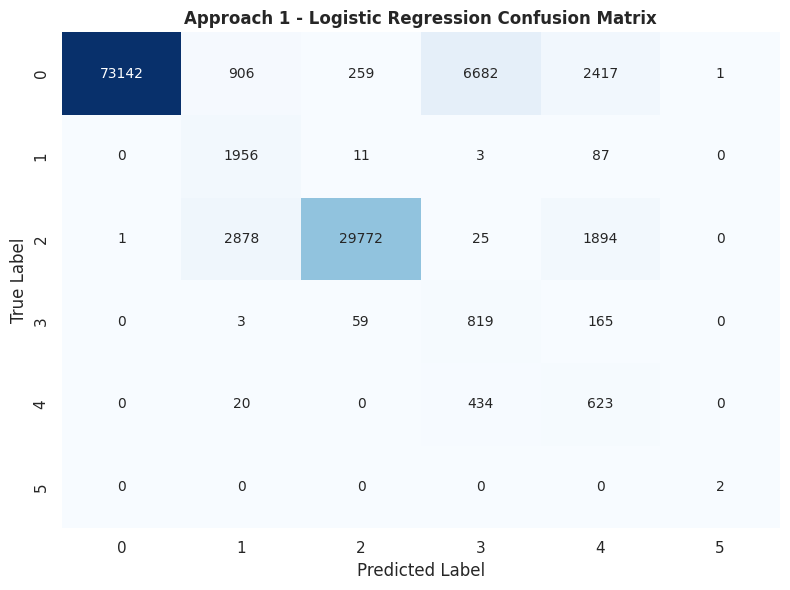


Decision Tree
  Accuracy:        0.9941
  Precision (macro): 0.9459
  Recall (macro):    0.9868
  F1-Score (macro):  0.9647

Per-class breakdown:
                  precision    recall  f1-score   support

          BENIGN       1.00      0.99      1.00     83407
   DoS GoldenEye       0.97      0.99      0.98      2057
        DoS Hulk       1.00      1.00      1.00     34570
DoS Slowhttptest       0.93      0.98      0.96      1046
   DoS slowloris       0.78      0.95      0.86      1077
      Heartbleed       1.00      1.00      1.00         2

        accuracy                           0.99    122159
       macro avg       0.95      0.99      0.96    122159
    weighted avg       0.99      0.99      0.99    122159



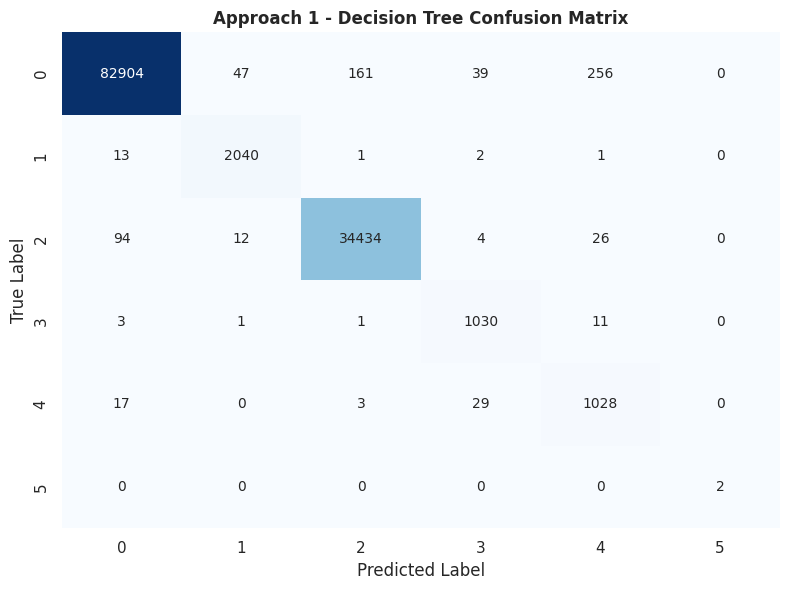


Random Forest
  Accuracy:        0.9938
  Precision (macro): 0.9451
  Recall (macro):    0.9928
  F1-Score (macro):  0.9655

Per-class breakdown:
                  precision    recall  f1-score   support

          BENIGN       1.00      0.99      1.00     83407
   DoS GoldenEye       0.97      0.99      0.98      2057
        DoS Hulk       0.99      1.00      1.00     34570
DoS Slowhttptest       0.98      0.98      0.98      1046
   DoS slowloris       0.72      0.99      0.83      1077
      Heartbleed       1.00      1.00      1.00         2

        accuracy                           0.99    122159
       macro avg       0.95      0.99      0.97    122159
    weighted avg       0.99      0.99      0.99    122159



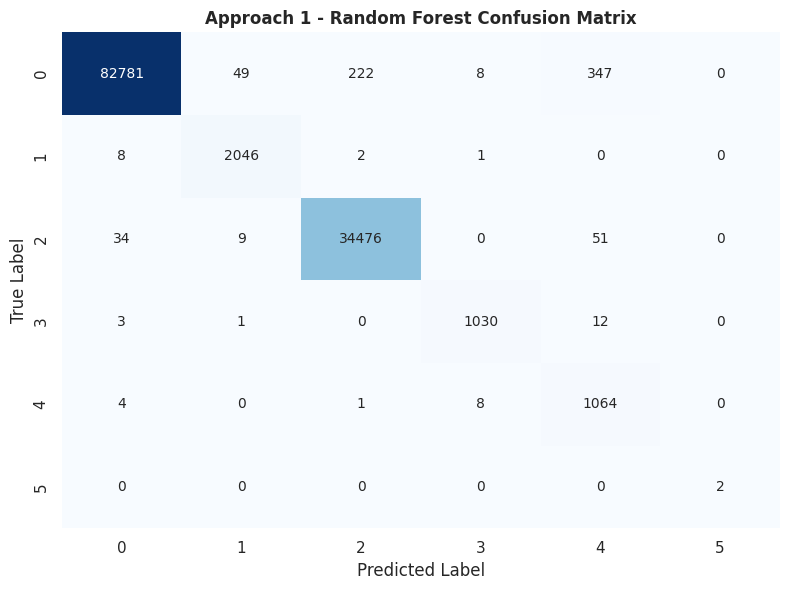


Logistic Regression
  Accuracy:        0.9014
  Precision (macro): 0.5339
  Recall (macro):    0.7353
  F1-Score (macro):  0.5847

Per-class breakdown:
                  precision    recall  f1-score   support

          BENIGN       1.00      0.93      0.96     83407
   DoS GoldenEye       0.33      0.84      0.47      2057
        DoS Hulk       0.98      0.86      0.92     34570
DoS Slowhttptest       0.02      0.09      0.03      1046
   DoS slowloris       0.21      0.69      0.32      1077
      Heartbleed       0.67      1.00      0.80         2

        accuracy                           0.90    122159
       macro avg       0.53      0.74      0.58    122159
    weighted avg       0.97      0.90      0.93    122159



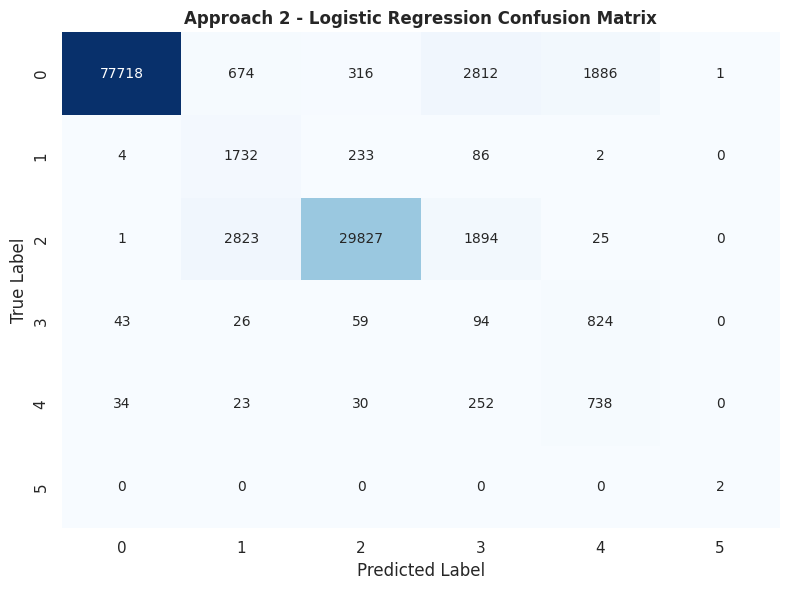


Decision Tree
  Accuracy:        0.9937
  Precision (macro): 0.9420
  Recall (macro):    0.9880
  F1-Score (macro):  0.9631

Per-class breakdown:
                  precision    recall  f1-score   support

          BENIGN       1.00      0.99      1.00     83407
   DoS GoldenEye       0.95      0.99      0.97      2057
        DoS Hulk       1.00      1.00      1.00     34570
DoS Slowhttptest       0.93      0.98      0.96      1046
   DoS slowloris       0.77      0.96      0.86      1077
      Heartbleed       1.00      1.00      1.00         2

        accuracy                           0.99    122159
       macro avg       0.94      0.99      0.96    122159
    weighted avg       0.99      0.99      0.99    122159



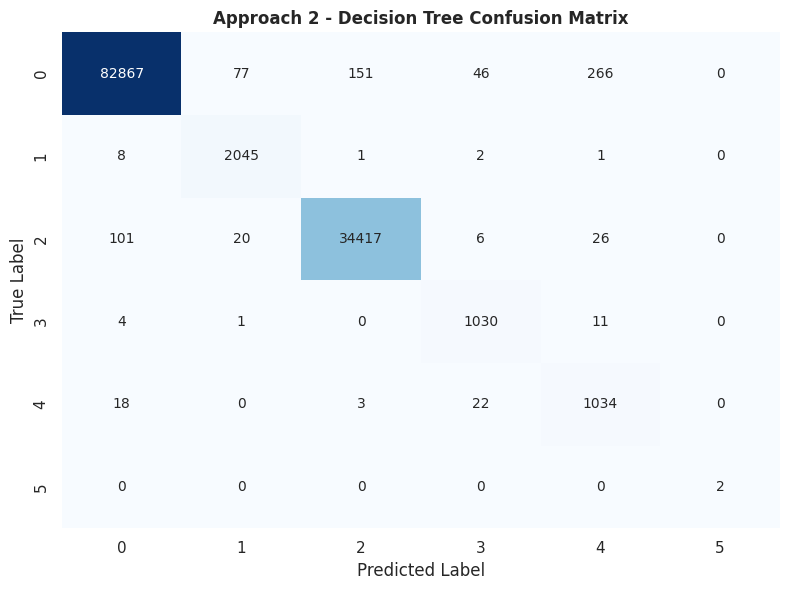


Random Forest
  Accuracy:        0.9934
  Precision (macro): 0.9406
  Recall (macro):    0.9934
  F1-Score (macro):  0.9631

Per-class breakdown:
                  precision    recall  f1-score   support

          BENIGN       1.00      0.99      1.00     83407
   DoS GoldenEye       0.96      1.00      0.98      2057
        DoS Hulk       0.99      1.00      1.00     34570
DoS Slowhttptest       0.98      0.99      0.98      1046
   DoS slowloris       0.71      0.99      0.83      1077
      Heartbleed       1.00      1.00      1.00         2

        accuracy                           0.99    122159
       macro avg       0.94      0.99      0.96    122159
    weighted avg       0.99      0.99      0.99    122159



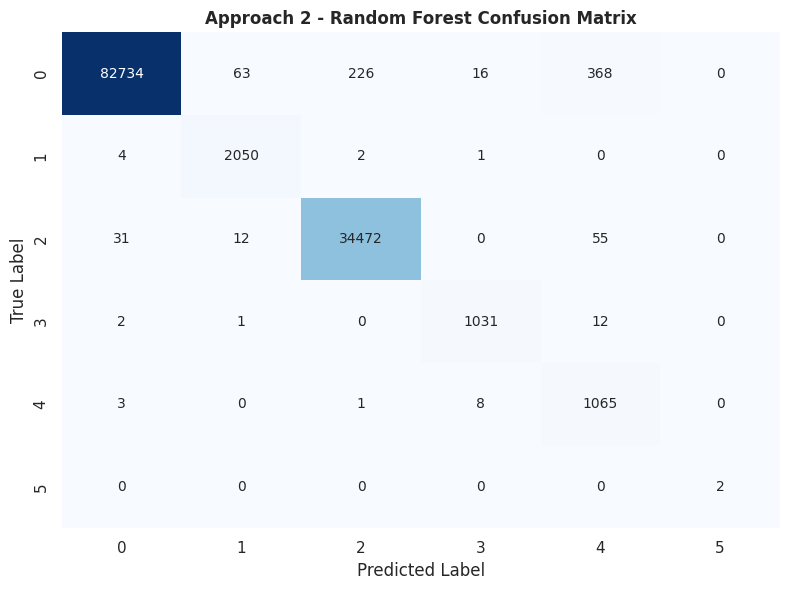

In [9]:
"""
SECTION 6: EVALUATION METRICS AND CONFUSION MATRICES
"""

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title, fontweight='bold', fontsize=12)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Print classification metrics — all averages are macro to treat each class equally
def print_metrics(y_true, y_pred, title):
    print(f"\n{title}")
    print(f"  Accuracy:        {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision (macro): {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall (macro):    {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score (macro):  {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"\nPer-class breakdown:")
    print(classification_report(y_true, y_pred, target_names=le_target.classes_, zero_division=0))

# APPROACH 1 - Evaluation on Test Set

for algo in results_approach.keys():
    print_metrics(y_test, results_approach[algo]['y_test_pred'], f"{algo}")
    plot_confusion_matrix(y_test, results_approach[algo]['y_test_pred'],
                         f"Approach 1 - {algo} Confusion Matrix")

# APPROACH 2 - Evaluation on Test Set

for algo in results_approach2.keys():
    print_metrics(y_test, results_approach2[algo]['y_test_pred'], f"{algo}")
    plot_confusion_matrix(y_test, results_approach2[algo]['y_test_pred'],
                         f"Approach 2 - {algo} Confusion Matrix")

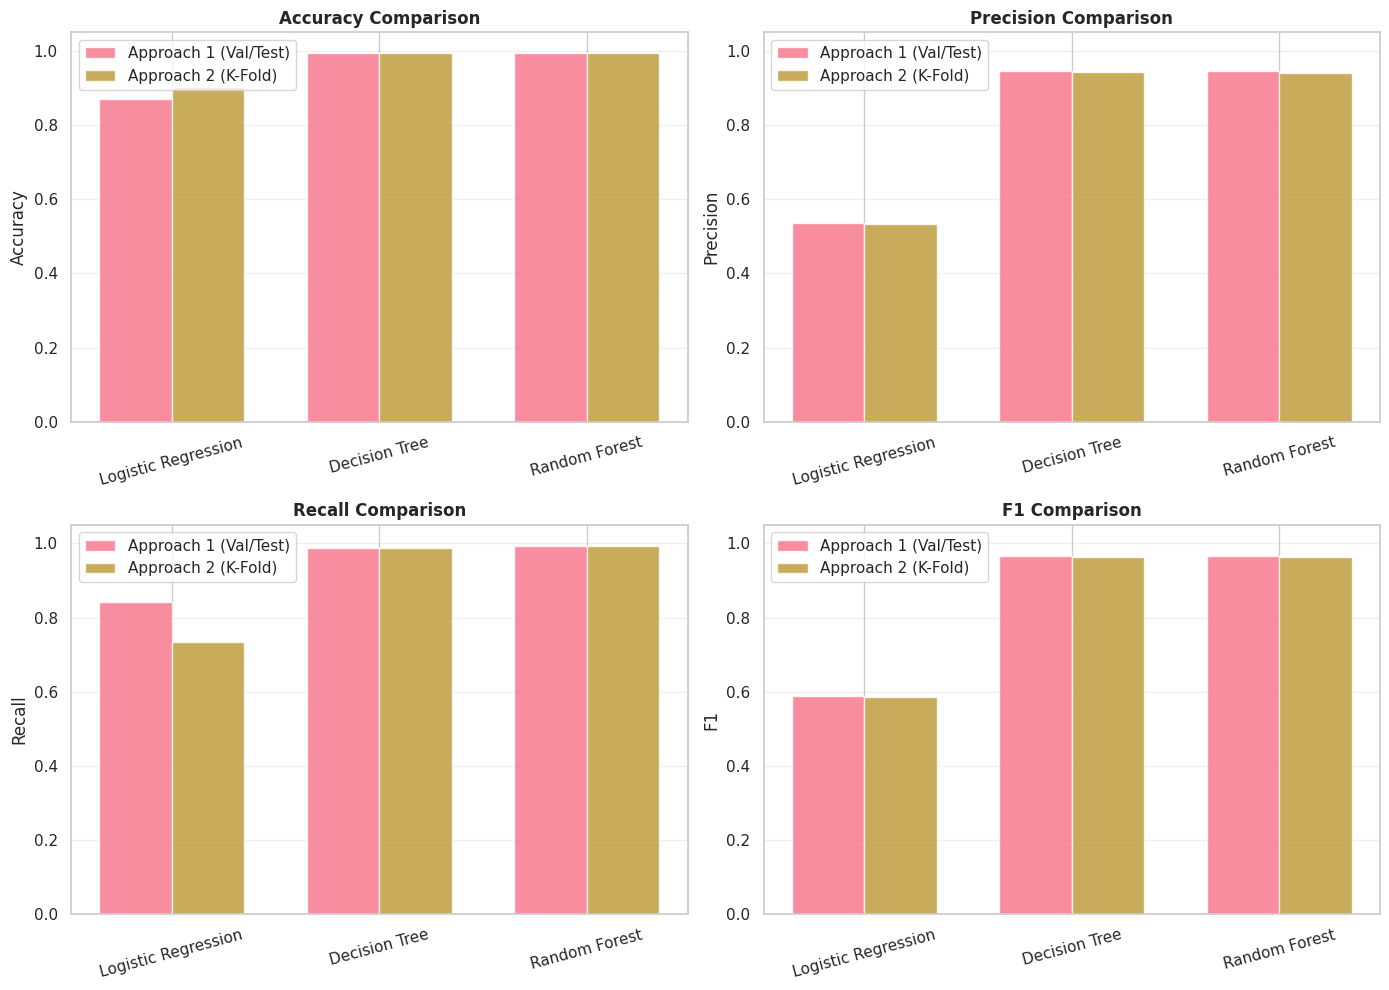

In [10]:
"""
SECTION 7: PERFORMANCE VISUALIZATION
"""

# Extract metrics for visualization
algorithms = list(results_approach.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics):
    approach_vals = [results_approach[algo]['test_metrics'][metric] for algo in algorithms]
    approach2_vals = [results_approach2[algo]['test_metrics'][metric] for algo in algorithms]
    
    x = np.arange(len(algorithms))
    width = 0.35
    
    axes[idx].bar(x - width/2, approach_vals, width, label='Approach 1 (Val/Test)', alpha=0.8)
    axes[idx].bar(x + width/2, approach2_vals, width, label='Approach 2 (K-Fold)', alpha=0.8)
    
    axes[idx].set_ylabel(metric.capitalize())
    axes[idx].set_title(f'{metric.capitalize()} Comparison', fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(algorithms, rotation=15)
    axes[idx].legend()
    axes[idx].set_ylim([0, 1.05])
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
"""
SECTION 8: DETAILED CONCLUSIONS AND ANALYSIS
"""

# Find best models for each approach
best_algo_a1 = max(results_approach.items(), 
                   key=lambda x: x[1]['test_metrics']['f1'])[0]
best_f1_a1 = results_approach[best_algo_a1]['test_metrics']['f1']

best_algo_a2 = max(results_approach2.items(), 
                   key=lambda x: x[1]['test_metrics']['f1'])[0]
best_f1_a2 = results_approach2[best_algo_a2]['test_metrics']['f1']

print(f"\n1. BEST PERFORMING MODELS:")
print(f"   Approach 1 (Train/Validation/Test Split):")
print(f"     - Algorithm: {best_algo_a1}")
print(f"     - Test Accuracy: {results_approach[best_algo_a1]['test_metrics']['accuracy']:.4f}")
print(f"     - Test F1-Score: {best_f1_a1:.4f}")

print(f"\n   Approach 2 (K-Fold Cross-Validation):")
print(f"     - Algorithm: {best_algo_a2}")
print(f"     - Test Accuracy: {results_approach2[best_algo_a2]['test_metrics']['accuracy']:.4f}")
print(f"     - Test F1-Score: {best_f1_a2:.4f}")

print(f"\n2. HYPERPARAMETER OPTIMIZATION ANALYSIS:")

param_differences = 0
for algo in algorithms:
    params_a1 = results_approach[algo]['best_params']
    params_a2 = results_approach2[algo]['best_params']
    if params_a1 != params_a2:
        param_differences += 1
        print(f"\n   {algo}:")
        print(f"     Approach 1 params: {params_a1}")
        print(f"     Approach 2 params: {params_a2}")

if param_differences == 0:
    print("   Both approaches selected identical hyperparameters for all algorithms.")
else:
    print(f"\n   {param_differences} out of {len(algorithms)} algorithms showed different hyperparameter selection.")

print(f"\n3. APPROACH COMPARISON:")

# Compare overall performance
a1_avg_f1 = np.mean([results_approach[algo]['test_metrics']['f1'] for algo in algorithms])
a2_avg_f1 = np.mean([results_approach2[algo]['test_metrics']['f1'] for algo in algorithms])

print(f"   Average F1-Score:")
print(f"     - Approach 1: {a1_avg_f1:.4f}")
print(f"     - Approach 2: {a2_avg_f1:.4f}")

if abs(a1_avg_f1 - a2_avg_f1) < 0.01:
    print(f"     Performance is very similar (difference < 0.01)")
else:
    better = "Approach 1" if a1_avg_f1 > a2_avg_f1 else "Approach 2"
    diff = abs(a1_avg_f1 - a2_avg_f1)
    print(f"     {better} performs better by {diff:.4f}")

print(f"\n4. ALGORITHM RANKING (by Test F1-Score):")
ranked = sorted([(algo, results_approach2[algo]['test_metrics']['f1']) 
                 for algo in algorithms], key=lambda x: x[1], reverse=True)
for rank, (algo, score) in enumerate(ranked, 1):
    print(f"   {rank}. {algo}: {score:.4f}")



1. BEST PERFORMING MODELS:
   Approach 1 (Train/Validation/Test Split):
     - Algorithm: Random Forest
     - Test Accuracy: 0.9938
     - Test F1-Score: 0.9655

   Approach 2 (K-Fold Cross-Validation):
     - Algorithm: Decision Tree
     - Test Accuracy: 0.9937
     - Test F1-Score: 0.9631

2. HYPERPARAMETER OPTIMIZATION ANALYSIS:

   Logistic Regression:
     Approach 1 params: {'classifier__C': 10, 'classifier__max_iter': 200, 'classifier__solver': 'lbfgs'}
     Approach 2 params: {'classifier__C': 10, 'classifier__max_iter': 200, 'classifier__solver': 'liblinear'}

   Decision Tree:
     Approach 1 params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}
     Approach 2 params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 5}

   Random Forest:
     Approach 1 params: {'classifier__criterion': 'gini', 'cla